In [41]:
import pandas as pd
messages = pd.read_csv('/kaggle/input/datasets/msp689/smsspam/SMSSpamCollection.txt',sep = "\t",names = ["labels","message"])

In [42]:
messages

,labels,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


## Data Cleaning and Preprocessing


In [43]:
import re        #regularization
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [44]:
corpus = []
for i in range(0,len(messages)):
    review = re.sub('[^a-zA-z]', ' ',messages['message'][i]) ## Keep only alphabets and any other character will be get replaced by space
    review = review.lower()
    review = review.split()
    review = [lemmatizer.lemmatize(word,pos='v') for word in review if word not in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)

## Tfidf

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
Tfidf = TfidfVectorizer(max_features = 2500,ngram_range=(1,2))

In [46]:
## Independent
X=Tfidf.fit_transform(corpus).toarray()

In [47]:
import numpy as np

np.set_printoptions(threshold=np.inf)
print(X[0])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

In [48]:
X.shape

(5572, 2500)

In [49]:
## Output
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(messages['labels'])

In [50]:
y

array([0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [52]:
from sklearn.naive_bayes import MultinomialNB ## Works well with sparse data
spam_detector = MultinomialNB()

In [53]:
spam_detector.fit(X_train,y_train)

MultinomialNB()

In [54]:
y_pred = spam_detector.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay,confusion_matrix,classification_report
accuracy = accuracy_score(y_pred,y_test)
print(accuracy)

0.9829596412556054


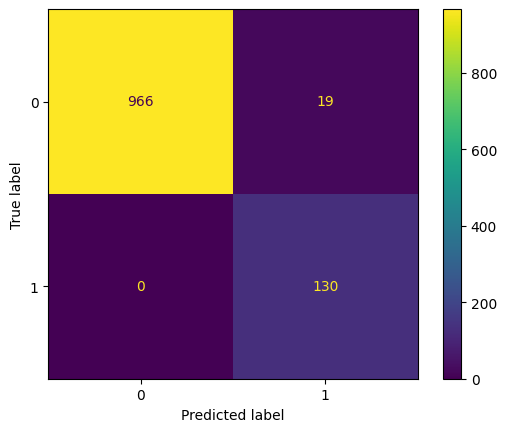

In [56]:
import matplotlib.pyplot as plt
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_pred,y_test)).plot()
plt.show()

In [57]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       985
           1       0.87      1.00      0.93       130

    accuracy                           0.98      1115
   macro avg       0.94      0.99      0.96      1115
weighted avg       0.99      0.98      0.98      1115

